# Phase 3: Supervised Learning for False Positive Reduction

## Task 3.5: Ensembles — Voting and Stacking

This notebook combines the individual Phase 3 classifiers into **ensemble models** that distinguish benign and attack flows more reliably than a single model.

It uses the **same fixed Phase 3 flow splits** as the Random Forest, XGBoost, SVM, and Neural Network notebooks, ensuring that all models are evaluated using identical data.

Three base classifiers are used:

* Random Forest
* XGBoost
* Support Vector Machine (SVM)

These classifiers are combined using two ensemble techniques:

* **Soft Voting:** Averages the predicted probabilities from the base classifiers.
* **Stacking:** Trains a meta-model to learn how to combine the predictions from the base classifiers.

### Why Use Ensembles?

Each base classifier may make different prediction errors. Combining their outputs through voting or stacking can reduce individual model errors and produce a more stable and accurate Stage 2 classifier for the two-stage intrusion detection cascade.

**Authors:** Arun and Nikhil


## Setup and load the fixed flow splits

In [1]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve
)


def find_project_root(start):
    """Walk up from `start` until the folder containing src/data/flow_preprocessing.py is found."""
    marker = Path("src") / "data" / "flow_preprocessing.py"
    for candidate in [start, *start.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root (no src/data/flow_preprocessing.py found above "
        f"{start}). Place this notebook inside the multi-stage-iot-ids repo under notebooks/ "
        "and run it from there."
    )

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

from src.data.flow_preprocessing import ATTACK_COL, BINARY_COL, FLOW_KEY_COL, TARGET_COL, build_flow_preprocessor

DATA_FOLDER = "phase3"
DATA_DIR = PROJECT_ROOT / "data" / "processed" / DATA_FOLDER
META_PATH = DATA_DIR / "flow_split_metadata.json"

with open(META_PATH, "r") as f:
    metadata = json.load(f)

train_df = pd.read_csv(DATA_DIR / "flow_train.csv", low_memory=False)
validation_df = pd.read_csv(DATA_DIR / "flow_validation.csv", low_memory=False)
test_df = pd.read_csv(DATA_DIR / "flow_test.csv", low_memory=False)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)
metadata

Project root: /Users/anandanto/Documents/ECE 597/multi-stage-iot-ids
Train shape: (89593, 89)
Validation shape: (19199, 89)
Test shape: (19199, 89)


{'input_path': 'data/samples/flow_sample_seed1.csv',
 'seed': 1,
 'validation_size': 0.15,
 'test_size': 0.15,
 'raw_rows': 127991,
 'clean_rows': 127991,
 'feature_count': 80,
 'feature_columns': ['Src Port',
  'Dst Port',
  'Protocol',
  'Flow Duration',
  'Total Fwd Packet',
  'Total Bwd packets',
  'Total Length of Fwd Packet',
  'Total Length of Bwd Packet',
  'Fwd IAT Total',
  'Bwd IAT Total',
  'Fwd PSH Flags',
  'Bwd PSH Flags',
  'Fwd URG Flags',
  'Bwd URG Flags',
  'Fwd Header Length',
  'Bwd Header Length',
  'FIN Flag Count',
  'SYN Flag Count',
  'RST Flag Count',
  'PSH Flag Count',
  'ACK Flag Count',
  'URG Flag Count',
  'CWR Flag Count',
  'ECE Flag Count',
  'Subflow Fwd Packets',
  'Subflow Fwd Bytes',
  'Subflow Bwd Packets',
  'Subflow Bwd Bytes',
  'Fwd Act Data Pkts',
  'Fwd Packet Length Max',
  'Bwd Packet Length Max',
  'Flow IAT Max',
  'Fwd IAT Max',
  'Bwd IAT Max',
  'Packet Length Max',
  'Active Max',
  'Idle Max',
  'Fwd Packet Length Min',
  'Bwd Pa

### Verify the class distribution and split integrity

In [2]:
for name, current_df in [("Train", train_df), ("Validation", validation_df), ("Test", test_df)]:
    print(f"{name} binary counts")
    print(current_df[BINARY_COL].value_counts())
    print()

train_keys = set(train_df[FLOW_KEY_COL])
validation_keys = set(validation_df[FLOW_KEY_COL])
test_keys = set(test_df[FLOW_KEY_COL])

print("Flow-key overlap")
print("  train n validation:", len(train_keys & validation_keys))
print("  train n test:", len(train_keys & test_keys))
print("  validation n test:", len(validation_keys & test_keys))

Train binary counts
binary_label
benign    86064
attack     3529
Name: count, dtype: int64

Validation binary counts
binary_label
benign    18443
attack      756
Name: count, dtype: int64

Test binary counts
binary_label
benign    18443
attack      756
Name: count, dtype: int64

Flow-key overlap
  train n validation: 0
  train n test: 0
  validation n test: 0


## Feature preparation

The models use the numeric flow-behaviour features recorded in the split metadata. Labels, flow
identifiers, IP addresses, timestamps, and source-file information are excluded.

Each base model gets its own preprocessing inside its own pipeline: the tree models (Random Forest,
XGBoost) do not need scaling, while the SVM does. Building the preprocessing into each pipeline means
the ensemble can mix scaled and unscaled models safely, and there is no data leakage because the
preprocessing is fit inside cross-validation.

In [3]:
feature_cols = metadata["feature_columns"]
missing_features = [col for col in feature_cols if col not in train_df.columns]

if missing_features:
    raise ValueError(f"Missing model features: {missing_features}")

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL].to_numpy()

X_validation = validation_df[feature_cols]
y_validation = validation_df[TARGET_COL].to_numpy()

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL].to_numpy()

print("Input features:", len(feature_cols))
print("Training missing values:", int(X_train.isna().sum().sum()))

Input features: 80
Training missing values: 136


## Build the base learners

Three base classifiers, each configured like its standalone Phase 3 notebook and each handling
class imbalance in its own natural way:

- **Random Forest** — `class_weight="balanced_subsample"` so rare attacks are not ignored.
- **XGBoost** — `scale_pos_weight` set from the training class ratio.
- **SVM** — a calibrated `LinearSVC` with `class_weight="balanced"`; calibration gives it the
  probability output that soft voting and stacking need.

All three must expose `predict_proba`, because both ensemble methods combine probabilities rather than
hard labels.

In [4]:
RANDOM_STATE = 1
CLASSIFICATION_THRESHOLD = 0.50

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)
print("scale_pos_weight:", round(scale_pos_weight, 4))

rf_pipeline = Pipeline([
    ("preprocessor", build_flow_preprocessor(scale=False)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline([
    ("preprocessor", build_flow_preprocessor(scale=False)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

svm_pipeline = Pipeline([
    ("preprocessor", build_flow_preprocessor(scale=True)),
    ("model", CalibratedClassifierCV(
        estimator=LinearSVC(
            class_weight="balanced",
            dual=False,
            max_iter=20000,
            random_state=RANDOM_STATE
        ),
        method="sigmoid",
        cv=3
    ))
])

base_estimators = [("random_forest", rf_pipeline), ("xgboost", xgb_pipeline), ("svm", svm_pipeline)]
print("Base learners:", [name for name, _ in base_estimators])

scale_pos_weight: 24.3876
Base learners: ['random_forest', 'xgboost', 'svm']


## Build and train the two ensembles

**Soft Voting** averages the three base models' predicted attack probabilities and thresholds the
average. It is simple, fast, and hard to overfit.

**Stacking** trains the three base models, collects their out-of-fold probabilities, and feeds them to
a small logistic-regression meta-model that learns the best way to weigh them. `cv=3` produces the
out-of-fold predictions so the meta-model never sees a base model's prediction on data that base model
trained on.

In [5]:
voting_ensemble = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    n_jobs=-1
)

stacking_ensemble = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    stack_method="predict_proba",
    cv=3,
    n_jobs=-1
)

ensembles = {"Voting": voting_ensemble, "Stacking": stacking_ensemble}
fit_times = {}

for name, model in ensembles.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - start
    print(f"{name} ensemble trained in {fit_times[name]:.2f} seconds")

Voting ensemble trained in 38.90 seconds
Stacking ensemble trained in 116.61 seconds


## Evaluate both ensembles

In [6]:
def evaluate_binary_classifier(model_name, dataset_name, y_true, scores, threshold, prediction_time):
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "model": model_name,
        "dataset": dataset_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "alerts": int(y_pred.sum()),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "prediction_time_sec": prediction_time
    }
    return result, y_pred

rows = []
predictions = {}
test_scores_by_model = {}

for name, model in ensembles.items():
    val_scores = model.predict_proba(X_validation)[:, 1]

    start = time.perf_counter()
    test_scores = model.predict_proba(X_test)[:, 1]
    test_time = time.perf_counter() - start
    test_scores_by_model[name] = test_scores

    val_row, _ = evaluate_binary_classifier(name, "Validation", y_validation, val_scores, CLASSIFICATION_THRESHOLD, np.nan)
    test_row, test_pred = evaluate_binary_classifier(name, "Test", y_test, test_scores, CLASSIFICATION_THRESHOLD, test_time)
    rows.extend([val_row, test_row])
    predictions[name] = test_pred

metrics_df = pd.DataFrame(rows)
display(metrics_df.round(4))

# Pick the stronger ensemble by test PR-AUC for the detailed diagnostics below.
best_name = metrics_df[metrics_df["dataset"] == "Test"].sort_values("pr_auc", ascending=False).iloc[0]["model"]
best_pred = predictions[best_name]
best_scores = test_scores_by_model[best_name]
print("Best ensemble by test PR-AUC:", best_name)

,model,dataset,threshold,accuracy,precision,recall,f1,specificity,fpr,fnr,roc_auc,pr_auc,alerts,tn,fp,fn,tp,prediction_time_sec
0,Voting,Validation,0.5,0.9884,0.9603,0.7368,0.8338,0.9988,0.0012,0.2632,0.9792,0.8818,580,18420,23,199,557,NaN
1,Voting,Test,0.5,0.9874,0.9573,0.7116,0.8164,0.9987,0.0013,0.2884,0.9769,0.8679,562,18419,24,218,538,0.2184
2,Stacking,Validation,0.5,0.9541,0.4576,0.8915,0.6048,0.9567,0.0433,0.1085,0.9800,0.8832,1473,17644,799,82,674,NaN
3,Stacking,Test,0.5,0.9562,0.4705,0.8849,0.6143,0.9592,0.0408,0.1151,0.9780,0.8727,1422,17690,753,87,669,0.2214


Best ensemble by test PR-AUC: Stacking


### Confusion matrices for both ensembles

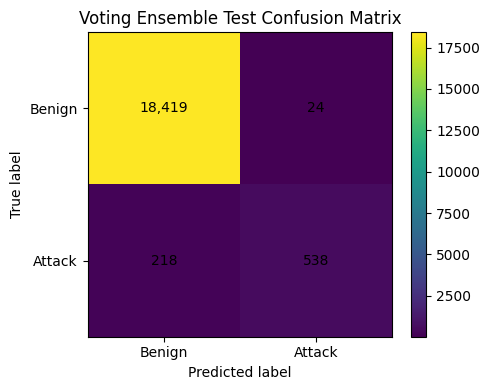

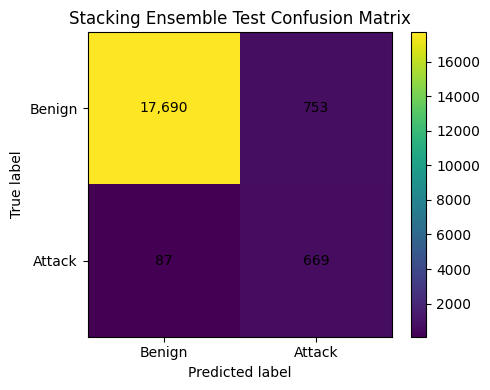

In [7]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Benign", "Attack"])
    plt.yticks([0, 1], ["Benign", "Attack"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

for name in ensembles:
    plot_confusion_matrix(y_test, predictions[name], f"{name} Ensemble Test Confusion Matrix")

### Test classification report (best ensemble)

In [8]:
report = classification_report(
    y_test, best_pred, target_names=["Benign", "Attack"], output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T
print("Classification report for:", best_name)
display(report_df.round(4))

Classification report for: Stacking


,precision,recall,f1-score,support
Benign,0.9951,0.9592,0.9768,18443.0000
Attack,0.4705,0.8849,0.6143,756.0000
accuracy,0.9562,0.9562,0.9562,0.9562
macro avg,0.7328,0.9220,0.7956,19199.0000
weighted avg,0.9744,0.9562,0.9625,19199.0000


### Results by traffic type (best ensemble)

,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,18443,17690,753,95.92
DDoS-HTTP Flood,147,146,1,99.32
DoS-HTTP Flood,153,146,7,95.42
DNS Spoofing,152,101,51,66.45
Brute Force,146,135,11,92.47
XSS,158,141,17,89.24


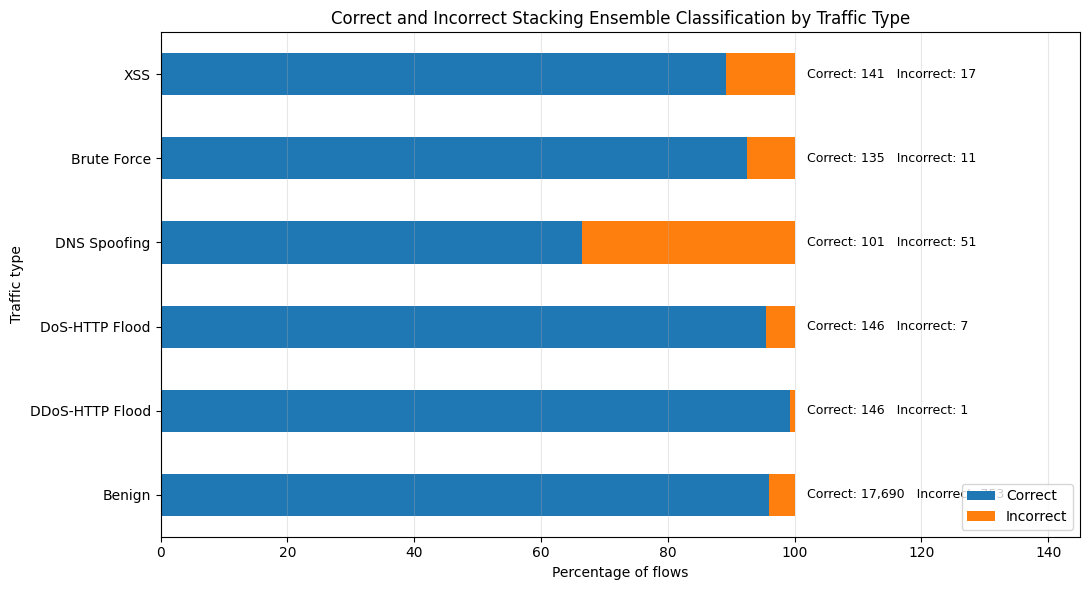

In [9]:
type_results = test_df[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = best_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))
for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)
ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of flows")
ax.set_ylabel("Traffic type")
ax.set_title(f"Correct and Incorrect {best_name} Ensemble Classification by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### ROC and precision-recall curves (both ensembles)

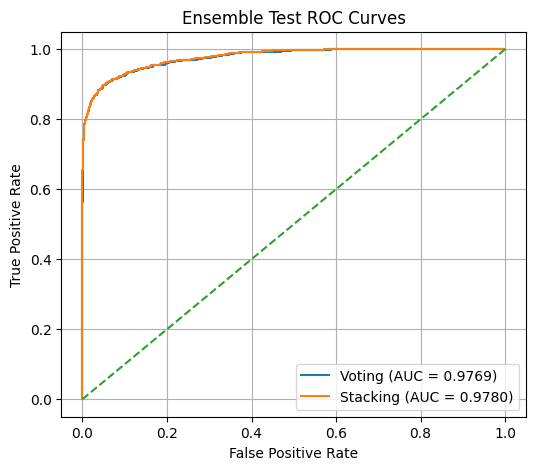

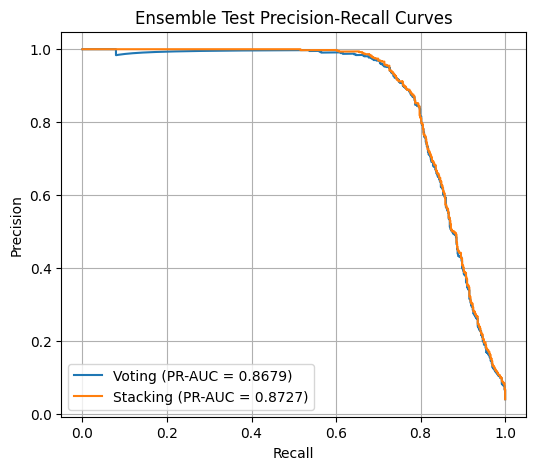

In [10]:
plt.figure(figsize=(6, 5))
for name in ensembles:
    fpr, tpr, _ = roc_curve(y_test, test_scores_by_model[name])
    auc_value = roc_auc_score(y_test, test_scores_by_model[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Ensemble Test ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))
for name in ensembles:
    precision, recall, _ = precision_recall_curve(y_test, test_scores_by_model[name])
    pr_auc = average_precision_score(y_test, test_scores_by_model[name])
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Ensemble Test Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

## Save the ensemble results

Results are written to `reports/phase3/` using the same convention as the other Phase 3 models, so the
cascade notebook and the final comparison table can pick them up automatically.

In [11]:
RESULTS_DIR = PROJECT_ROOT / "reports" / "phase3"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

metrics_output = metrics_df.copy()
for name in ensembles:
    metrics_output.loc[metrics_output["model"] == name, "fit_time_sec"] = fit_times[name]
metrics_output.to_csv(RESULTS_DIR / "ensemble_metrics.csv", index=False)

summary = {
    "base_learners": [name for name, _ in base_estimators],
    "ensembles": list(ensembles.keys()),
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "scale_pos_weight": scale_pos_weight,
    "fit_times_sec": fit_times,
    "best_ensemble_by_test_pr_auc": best_name
}
with open(RESULTS_DIR / "ensemble_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

prediction_cols = [FLOW_KEY_COL, ATTACK_COL, BINARY_COL, TARGET_COL]
test_predictions = test_df[prediction_cols].copy()
for name in ensembles:
    test_predictions[f"{name.lower()}_attack_probability"] = test_scores_by_model[name]
    test_predictions[f"{name.lower()}_prediction"] = predictions[name]
test_predictions.to_csv(RESULTS_DIR / "ensemble_test_predictions.csv", index=False)

print("Saved ensemble results to:", RESULTS_DIR)

Saved ensemble results to: /Users/anandanto/Documents/ECE 597/multi-stage-iot-ids/reports/phase3


## Final ensemble summary

In [12]:
print("Final ensemble test results")
print("---------------------------")
for name in ensembles:
    row = metrics_df[(metrics_df["model"] == name) & (metrics_df["dataset"] == "Test")].iloc[0]
    print(f"\n{name} ensemble")
    print(f"  Accuracy:  {row['accuracy']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  F1-score:  {row['f1']:.4f}")
    print(f"  ROC-AUC:   {row['roc_auc']:.4f}")
    print(f"  PR-AUC:    {row['pr_auc']:.4f}")
    print(f"  FPR:       {row['fpr']:.4f}")
    print(f"  FNR:       {row['fnr']:.4f}")

print(f"\nBest ensemble by test PR-AUC: {best_name}")
print("\nCorrect classification rate by traffic type (best ensemble)")
for attack_type in type_order:
    if attack_type in result_by_type.index:
        rate = result_by_type.loc[attack_type, "correct_rate"]
        print(f"  {attack_type}: {rate:.2f}%")

Final ensemble test results
---------------------------

Voting ensemble
  Accuracy:  0.9874
  Precision: 0.9573
  Recall:    0.7116
  F1-score:  0.8164
  ROC-AUC:   0.9769
  PR-AUC:    0.8679
  FPR:       0.0013
  FNR:       0.2884

Stacking ensemble
  Accuracy:  0.9562
  Precision: 0.4705
  Recall:    0.8849
  F1-score:  0.6143
  ROC-AUC:   0.9780
  PR-AUC:    0.8727
  FPR:       0.0408
  FNR:       0.1151

Best ensemble by test PR-AUC: Stacking

Correct classification rate by traffic type (best ensemble)
  Benign: 95.92%
  DDoS-HTTP Flood: 99.32%
  DoS-HTTP Flood: 95.42%
  DNS Spoofing: 66.45%
  Brute Force: 92.47%
  XSS: 89.24%
